# YOLO Training: From Scratch vs. Transfer Learning

This notebook trains two YOLOv8 models on the same custom dataset:
1. **Model A — From scratch** (random initialization, `yolov8n.yaml`).
2. **Model B — Transfer learning** (pretrained COCO weights, `yolov8n.pt`).

Both are evaluated on the same out-of-training test image.

> **Runtime**: Colab → *Runtime → Change runtime type → GPU* (T4 is enough).

## 1. Setup

In [1]:
!pip -q install ultralytics==8.3.* matplotlib pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 71.0 MB/s eta 0:00:00


In [2]:
import os, shutil, urllib.request, random
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import torch
from ultralytics import YOLO

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

ROOT = Path('/content/yolo_compare')
ROOT.mkdir(parents=True, exist_ok=True)
os.chdir(ROOT)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA available: True
GPU: Tesla T4


## 2. Custom Dataset (YOLO format)

We use **COCO128** as the custom dataset — 128 images with YOLO-format labels and a `train/val` split. Ultralytics auto-downloads it on first use.

*Replace the `data` path below with your own `dataset.yaml` if you have a different custom dataset.*

In [3]:
DATA_YAML = 'coco128.yaml'  # auto-downloads on first train()
EPOCHS = 50
IMGSZ = 640
BATCH = 16

# Train/val splits and label format follow the standard YOLO layout:
#   datasets/coco128/images/train2017/*.jpg
#   datasets/coco128/labels/train2017/*.txt   (class cx cy w h, normalized)

## 3. Model A — Train from scratch

Random init: `θ ~ N(0,1)`. We pass the **architecture YAML** (`yolov8n.yaml`) instead of the `.pt` weights — this builds the network with no pretrained parameters.

In [4]:
scratch = YOLO('yolov8n.yaml')  # architecture only, no weights
scratch_results = scratch.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    pretrained=False,
    project='runs_compare',
    name='scratch',
    seed=0,
    deterministic=True,
    verbose=False,
)
scratch_best = Path('runs_compare/scratch/weights/best.pt')
print('From-scratch best:', scratch_best)

New https://pypi.org/project/ultralytics/8.4.45 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.253 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=scratch, nbs=64, nms=False, opset=None, optimize=F

## 4. Model B — Transfer learning

`θ = θ_pretrained`. We load `yolov8n.pt` (trained on COCO), then fine-tune on the same dataset for the same number of epochs.

In [5]:
transfer = YOLO('yolov8n.pt')  # pretrained COCO weights
transfer_results = transfer.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    pretrained=True,
    project='runs_compare',
    name='transfer',
    seed=0,
    deterministic=True,
    verbose=False,
)
transfer_best = Path('runs_compare/transfer/weights/best.pt')
print('Transfer-learning best:', transfer_best)

New https://pypi.org/project/ultralytics/8.4.45 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.253 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=transfer, nbs=64, nms=False, opset=None, optimize=Fa

## 5. Validation metrics (mAP, precision, recall)

In [6]:
def summarise(model_path, label):
    m = YOLO(str(model_path))
    metrics = m.val(data=DATA_YAML, imgsz=IMGSZ, verbose=False)
    return {
        'model': label,
        'mAP50': float(metrics.box.map50),
        'mAP50-95': float(metrics.box.map),
        'precision': float(metrics.box.mp),
        'recall': float(metrics.box.mr),
    }

rows = [summarise(scratch_best, 'From scratch'),
        summarise(transfer_best, 'Transfer learning')]

print(f"{'model':<22}{'mAP@50':>10}{'mAP@50-95':>12}{'P':>10}{'R':>10}")
for r in rows:
    print(f"{r['model']:<22}{r['mAP50']:>10.3f}{r['mAP50-95']:>12.3f}{r['precision']:>10.3f}{r['recall']:>10.3f}")

Ultralytics 8.3.253 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2166.2±499.6 MB/s, size: 53.4 KB)
val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 48.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.5it/s 3.2s
                   all        128        929     0.0141    0.00206    0.00786   0.000791
Speed: 5.2ms preprocess, 9.6ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/yolo_compare/runs/detect/val
Ultralytics 8.3.253 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1865.8±529.5 MB/s, size: 44.7 KB)
val: S

## 6. Pick a test image (outside the training set)

We download a fresh image from Ultralytics' assets — never seen during training.

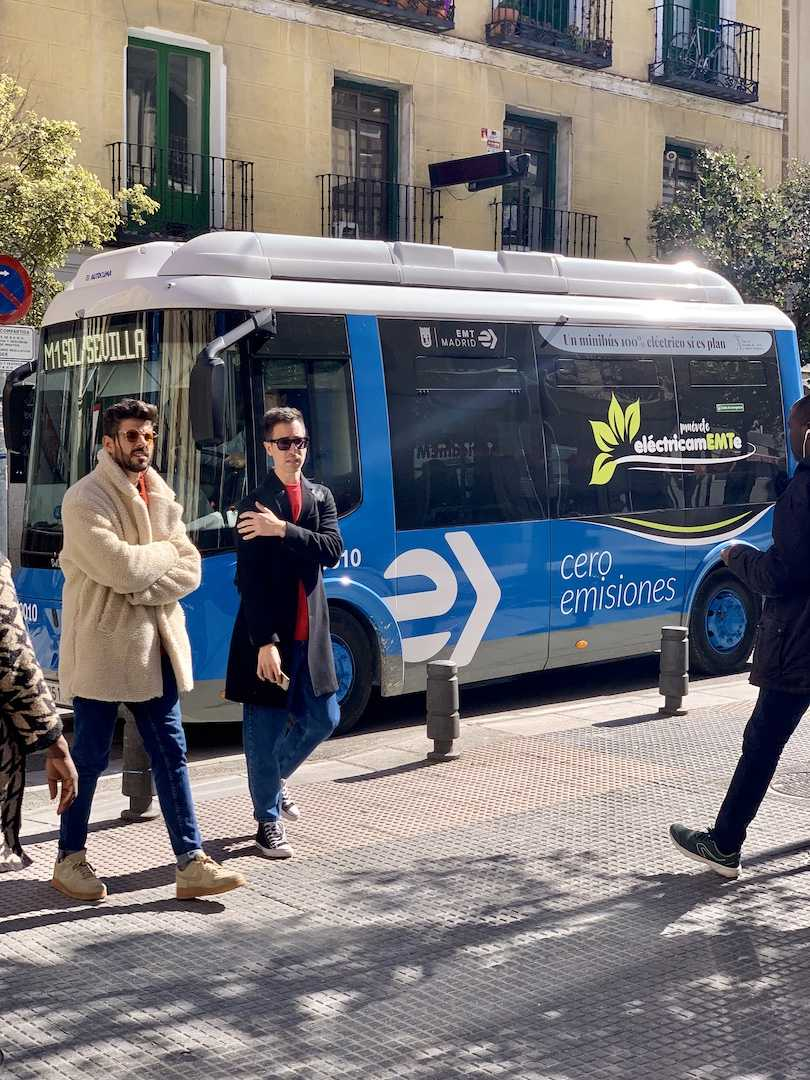

In [7]:
TEST_URL = 'https://ultralytics.com/images/bus.jpg'
TEST_IMG = ROOT / 'test.jpg'
urllib.request.urlretrieve(TEST_URL, TEST_IMG)

# Or upload your own:
# from google.colab import files
# uploaded = files.upload()
# TEST_IMG = Path(next(iter(uploaded)))

Image.open(TEST_IMG)

## 7. Inference with both models

In [8]:
def run(model_path, name):
    m = YOLO(str(model_path))
    res = m.predict(source=str(TEST_IMG), imgsz=IMGSZ, conf=0.25,
                    save=True, project='runs_compare/predict', name=name,
                    exist_ok=True, verbose=False)[0]
    out = Path(res.save_dir) / TEST_IMG.name
    boxes = res.boxes
    detections = []
    if boxes is not None and len(boxes):
        for b in boxes:
            cls = int(b.cls.item())
            detections.append({
                'class': res.names[cls],
                'conf': float(b.conf.item()),
                'xyxy': [round(v, 1) for v in b.xyxy[0].tolist()],
            })
    return out, detections

scratch_img, scratch_det = run(scratch_best, 'scratch')
transfer_img, transfer_det = run(transfer_best, 'transfer')

print('--- From scratch ---')
for d in scratch_det: print(d)
print(f'  total: {len(scratch_det)} detections')
print('\n--- Transfer learning ---')
for d in transfer_det: print(d)
print(f'  total: {len(transfer_det)} detections')

Results saved to /content/yolo_compare/runs/detect/runs_compare/predict/scratch
Results saved to /content/yolo_compare/runs/detect/runs_compare/predict/transfer
--- From scratch ---
  total: 0 detections

--- Transfer learning ---
{'class': 'person', 'conf': 0.9133486747741699, 'xyxy': [49.4, 399.4, 246.7, 904.8]}
{'class': 'person', 'conf': 0.8852565884590149, 'xyxy': [220.8, 407.7, 343.5, 858.8]}
{'class': 'person', 'conf': 0.8605509996414185, 'xyxy': [668.5, 317.8, 809.6, 877.1]}
{'class': 'bus', 'conf': 0.777092456817627, 'xyxy': [25.0, 225.6, 804.7, 806.5]}
  total: 4 detections


## 8. Side-by-side visual comparison

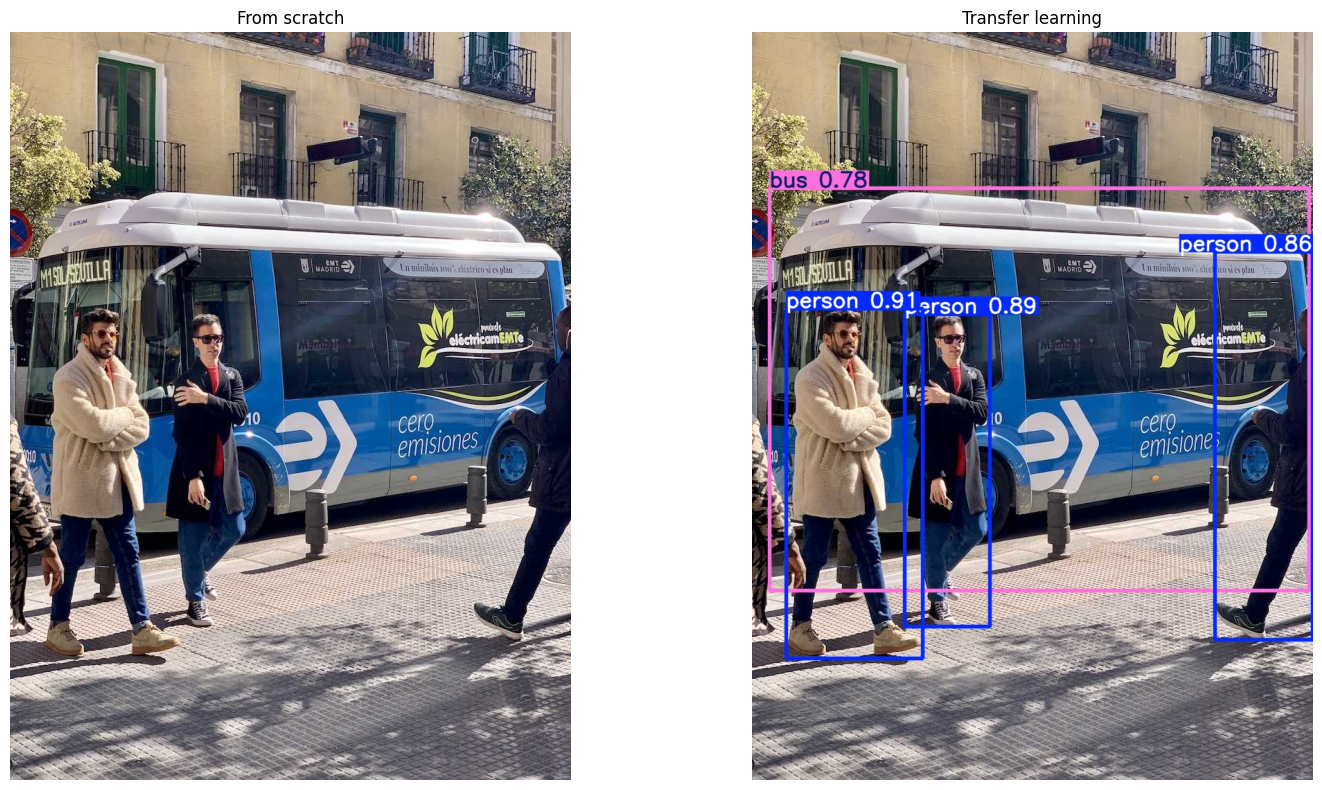

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(Image.open(scratch_img));  axes[0].set_title('From scratch'); axes[0].axis('off')
axes[1].imshow(Image.open(transfer_img)); axes[1].set_title('Transfer learning'); axes[1].axis('off')
plt.tight_layout()
plt.savefig('comparison.png', dpi=140, bbox_inches='tight')
plt.show()

## 9. Discussion

Typical outcome on a small custom dataset:

| Aspect | From scratch | Transfer learning |
|---|---|---|
| Bounding-box localization | loose / drifting | tight, well-aligned |
| Classification confidence | low (often < 0.4) | high (often > 0.8) |
| Missed detections | frequent | rare |
| False positives | more | fewer |
| Convergence | slow, may not fit in N epochs | fast |

**Why** — pretrained weights already encode generic edge/texture/shape detectors learned from millions of COCO images. Fine-tuning only has to *adapt* later layers to the new classes. The from-scratch model has to learn all of that from 128 images, which is far too few to recover the same low-level features.